In [1]:
import pandas as pd
import numpy as np
import matplotlib
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

scenario_parent_folder = Path(os.path.abspath('')) / 'logs' /  'unified' / 'p2p'

Ran with 
```
# Independent variables
independent_vars = {
    "nodeXCount" : [1],
    "nodeXSpacing": [1],
    "nodeXOffset": list(np.arange(0, 1.5, 0.05)) + list(np.arange(1.5, 1.9, 0.01)) + list(np.arange(1.9, 2.3, 0.05)),
    "nodeYCount" : [1],
    "nodeYSpacing": [1],
    "nodeYOffset": [0],
    "nodeZCount": [1],
    "nodeZSpacing": [1],
    "nodeZOffset": [0],
    "auvSpeed": [0],
    "propagationModel": ["underwater"],
    "waterTemperature": list(np.arange(0, 30)),
    "waterSalinity": [0.01, 0.5],
    "stopTime": [10*60],  # seconds
    "channelWidth": [1, 2],
    "packetStatsConfig": ["means"],
    "enablePositionLogging": ["true"],
    "powerLoggingConfig": ["short"],
    "enableMacStats": ["true"],
    "scenarioFolderPath": ["\"unified/p2p/run\""]
}

# Dependent variables defined via lambda functions. 
# Each lambda receives a dict with the current independent variables.
dependent_vars = {
    "dataRatePHY": lambda args: "OfdmRate1_2MbpsBW1MHz" if args["channelWidth"] == 1 else "OfdmRate7_8MbpsBW2MHz",
}
```

In [2]:
def read_sim_config_file(scenario_folder:Path) -> dict:
    sim_config = {}
    with open(scenario_folder / 'SimConfig.txt') as f:
        for line in f:
            if line.startswith('--'):
                key, value = line.strip().split('=')
                key = key[2:]  # Remove the leading '--'
                
                # Try to convert value to appropriate data type
                try:
                    # First try as int
                    sim_config[key] = int(value)
                except ValueError:
                    try:
                        # Then try as float
                        sim_config[key] = float(value)
                    except ValueError:
                        # Keep as string if not numeric
                        sim_config[key] = value
    return sim_config

In [3]:
# Get all the scenario folders
scenario_folders = sorted([x for x in scenario_parent_folder.iterdir() if x.is_dir()])
print(f"Will load {len(scenario_folders)} scenario runs")

packet_logging_stats_summary_dfs = []
power_state_stats = pd.DataFrame()
for i, scenario_folder in enumerate(scenario_folders):
    sim_config = read_sim_config_file(scenario_folder)
    print(f"[{i+1}/{len(scenario_folders)}] Loading scenario {scenario_folder.name}")

    # Load the packet logging stats
    if (scenario_folder / 'PacketLoggingStatsSummary.csv').exists():
        packet_logging_stats_summary_df = pd.read_csv(scenario_folder / 'PacketLoggingStatsSummary.csv', delimiter=';', index_col=False)
        for key, value in sim_config.items():
            packet_logging_stats_summary_df[key] = value
        packet_logging_stats_summary_dfs.append(packet_logging_stats_summary_df)
    else:
        print(f"PacketLoggingStatsSummary.csv not found in {scenario_folder.name}")
        
    # Load the power state stats
    if (scenario_folder / 'PowerStateStats.csv').exists():
        ps_temp_df = pd.read_csv(scenario_folder / 'PowerStateStats.csv', delimiter=';', index_col=False)
        for col in ['SLEEPTime', 'IDLETime', 'TXTime', 'RXTime', "CCA_BUSYTime", "SWITCHINGTime"]:
            ps_temp_df[col] = ps_temp_df[col].str.replace('ns', '').astype(float)
            # Ignore the APs as we assume they are always on
            power_state_stats.loc[i, col] = ps_temp_df[ps_temp_df['NodeType'] == "STA"][col].mean()
        for key, value in sim_config.items():
            power_state_stats.loc[i, key] = value
    else:
        print(f"PowerStateStats.csv not found in {scenario_folder.name}")
        
packet_logging_stats_summary = pd.concat(packet_logging_stats_summary_dfs)
for col in ['MeanLatencySTAToAP', 'MeanLatencyAPToSTA']:
    packet_logging_stats_summary[col] = abs(packet_logging_stats_summary[col].str.replace('ns', '').astype(float))

Will load 9360 scenario runs
[1/9360] Loading scenario run_1743182767323466543
[2/9360] Loading scenario run_1743182767323466599
[3/9360] Loading scenario run_1743182767323466664
[4/9360] Loading scenario run_1743182767323469956
[5/9360] Loading scenario run_1743182767323506568
[6/9360] Loading scenario run_1743182767323531672
[7/9360] Loading scenario run_1743182767323531707
[8/9360] Loading scenario run_1743182767323545158
[9/9360] Loading scenario run_1743182767323545913
[10/9360] Loading scenario run_1743182767323568323
[11/9360] Loading scenario run_1743182767323585415
[12/9360] Loading scenario run_1743182767323600640
[13/9360] Loading scenario run_1743182767323603539
[14/9360] Loading scenario run_1743182767323623415
[15/9360] Loading scenario run_1743182767323648563
[16/9360] Loading scenario run_1743182767323678539
[17/9360] Loading scenario run_1743182767323858210
[18/9360] Loading scenario run_1743182767324079279
[19/9360] Loading scenario run_1743182788196914438
[20/9360] L

In [4]:
packet_logging_stats_summary

,CountPacketsSentSTAToAP,CountPacketsSentAPToSTA,MeanPacketSizeSTAToAP,MeanPacketSizeAPToSTA,MeanTxBeginCountSTAToAP,MeanTxBeginCountAPToSTA,MeanRxEndCountSTAToAP,MeanRxEndCountAPToSTA,MeanRxDropCountSTAToAP,MeanRxDropCountAPToSTA,...,waterTemperature,waterSalinity,stopTime,channelWidth,packetStatsConfig,enablePositionLogging,powerLoggingConfig,enableMacStats,scenarioFolderPath,dataRatePHY
0,26515,28854,625.8800,90.0002,1,1,1,1,0,0,...,1,0.50,600,2,means,true,short,true,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
0,15520,17853,625.8300,89.9985,2,1,2,1,0,0,...,4,0.01,600,1,means,true,short,true,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
0,15520,17853,625.8300,89.9985,2,1,2,1,0,0,...,2,0.50,600,1,means,true,short,true,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
0,26515,28854,625.8800,90.0002,1,1,1,1,0,0,...,3,0.50,600,2,means,true,short,true,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
0,15520,17853,625.8300,89.9985,2,1,2,1,0,0,...,2,0.01,600,1,means,true,short,true,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,6,14,94.6667,92.5714,1562,2,1,1,1561,0,...,29,0.01,600,1,means,true,short,true,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
0,0,0,0.0000,0.0000,0,0,0,0,0,0,...,28,0.50,600,2,means,true,short,true,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
0,0,0,0.0000,0.0000,0,0,0,0,0,0,...,29,0.01,600,2,means,true,short,true,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
0,0,0,0.0000,0.0000,0,0,0,0,0,0,...,29,0.50,600,2,means,true,short,true,unified/p2p/run,OfdmRate7_8MbpsBW2MHz


In [5]:
power_state_stats

,SLEEPTime,IDLETime,TXTime,RXTime,CCA_BUSYTime,SWITCHINGTime,nodeXCount,nodeXSpacing,nodeXOffset,nodeYCount,...,waterTemperature,waterSalinity,stopTime,channelWidth,packetStatsConfig,enablePositionLogging,powerLoggingConfig,enableMacStats,scenarioFolderPath,dataRatePHY
0,1.701689e+11,2.362364e+11,9.445204e+10,9.910644e+10,35848000.0,0.0,1.0,1.0,0.00,1.0,...,1.0,0.50,600.0,2.0,means,true,short,true,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
1,1.540925e+11,1.936171e+11,1.714610e+11,8.083292e+10,0.0,0.0,1.0,1.0,0.00,1.0,...,4.0,0.01,600.0,1.0,means,true,short,true,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
2,1.540925e+11,1.936171e+11,1.714610e+11,8.083292e+10,0.0,0.0,1.0,1.0,0.00,1.0,...,2.0,0.50,600.0,1.0,means,true,short,true,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
3,1.701689e+11,2.362364e+11,9.445204e+10,9.910644e+10,35848000.0,0.0,1.0,1.0,0.00,1.0,...,3.0,0.50,600.0,2.0,means,true,short,true,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
4,1.540925e+11,1.936171e+11,1.714610e+11,8.083292e+10,0.0,0.0,1.0,1.0,0.00,1.0,...,2.0,0.01,600.0,1.0,means,true,short,true,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9355,8.490741e+10,4.261915e+11,5.959848e+10,2.930460e+10,0.0,0.0,1.0,1.0,2.25,1.0,...,29.0,0.01,600.0,1.0,means,true,short,true,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
9356,0.000000e+00,5.424000e+11,5.760288e+10,0.000000e+00,0.0,0.0,1.0,1.0,2.25,1.0,...,28.0,0.50,600.0,2.0,means,true,short,true,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
9357,0.000000e+00,4.781130e+11,5.760288e+10,6.428700e+10,0.0,0.0,1.0,1.0,2.25,1.0,...,29.0,0.01,600.0,2.0,means,true,short,true,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
9358,0.000000e+00,5.424000e+11,5.760288e+10,0.000000e+00,0.0,0.0,1.0,1.0,2.25,1.0,...,29.0,0.50,600.0,2.0,means,true,short,true,unified/p2p/run,OfdmRate7_8MbpsBW2MHz


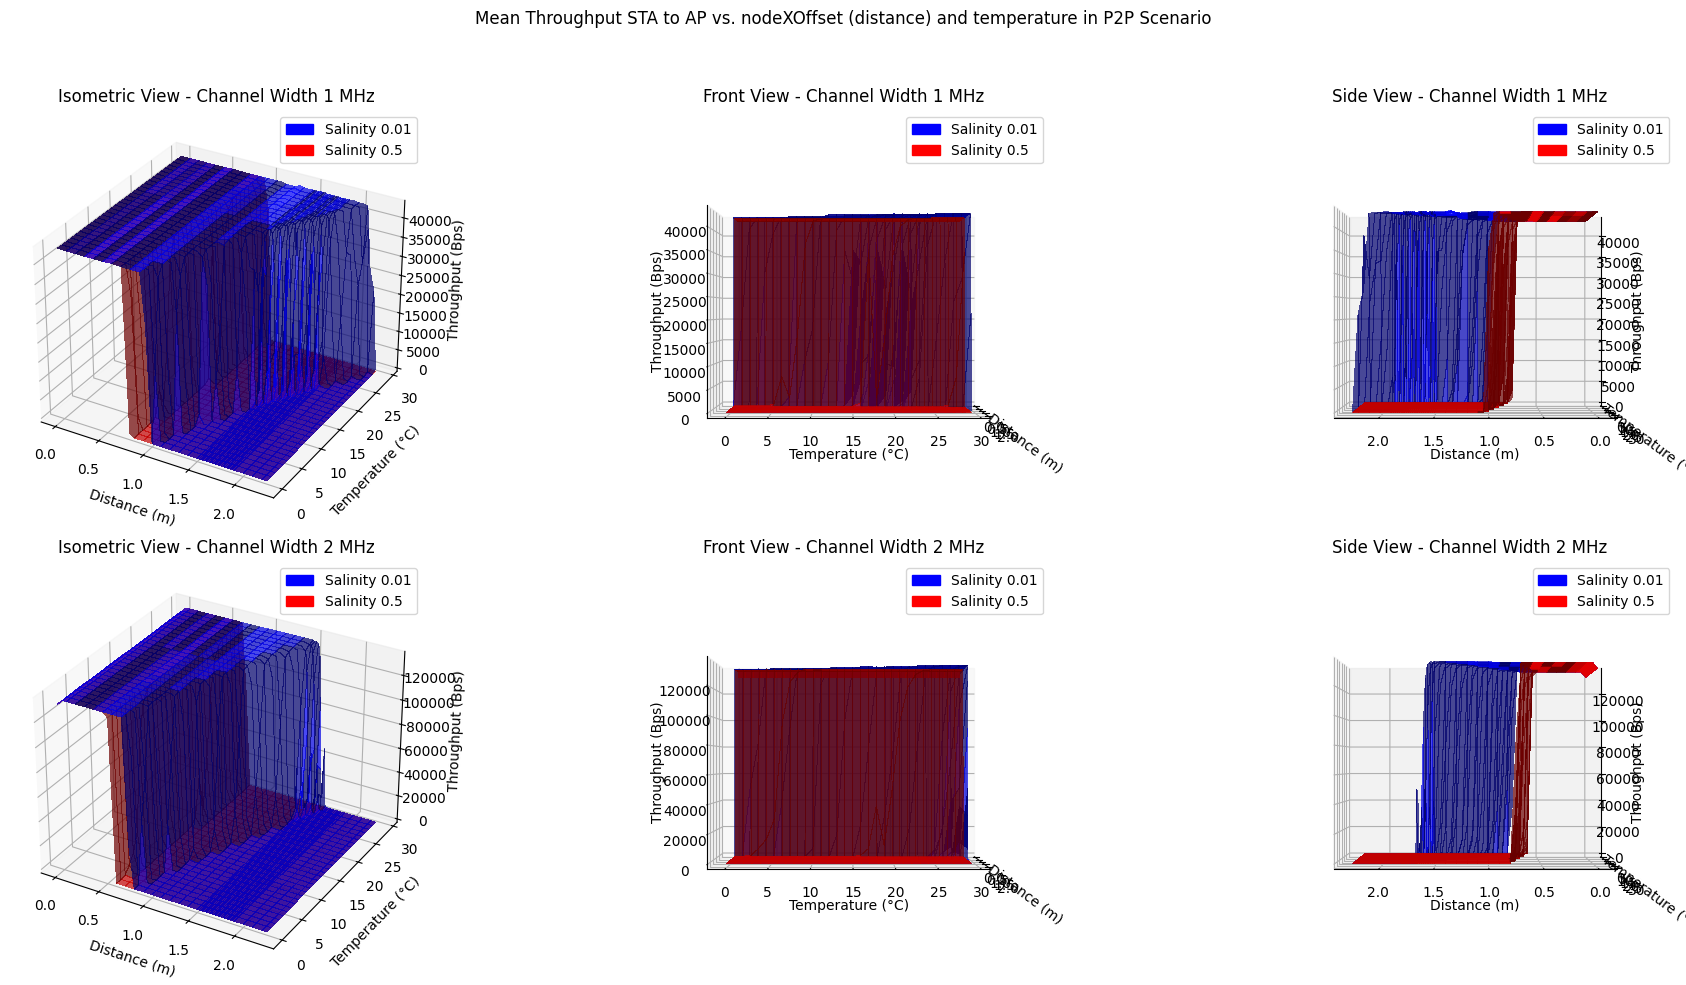

In [6]:
fig = plt.figure(figsize=(20, 10))
fig.suptitle('Mean Throughput STA to AP vs. nodeXOffset (distance) and temperature in P2P Scenario')

# Get unique values for each channel width and salinity
channel_widths = [1, 2]
salinity_values = [0.01, 0.5]

# Create a colormap for differentiating salinity
colors = ['blue', 'red']

# Process each channel width
for c_idx, channel_width in enumerate(channel_widths):
    # Filter data for this channel width
    filtered_data = packet_logging_stats_summary[packet_logging_stats_summary['channelWidth'] == channel_width]
    
    # Determine the subplot positions
    positions = [1, 2, 3] if c_idx == 0 else [4, 5, 6]
    views = ["Isometric", "Front", "Side"]
    elevs = [None, 0, 0]  # None = default for isometric
    azims = [None, 0, 90]  # None = default for isometric
    
    # Create subplots for different views
    for i, (pos, view, elev, azim) in enumerate(zip(positions, views, elevs, azims)):
        ax = fig.add_subplot(2, 3, pos, projection='3d')
        
        # Plot each salinity value
        for s_idx, salinity in enumerate(salinity_values):
            # Filter data for this salinity
            salinity_data = filtered_data[filtered_data['waterSalinity'] == salinity]
            
            # Create a 2D grid for surface plot
            x_unique = np.sort(salinity_data['nodeXOffset'].unique())
            y_unique = np.sort(salinity_data['waterTemperature'].unique())
            
            X, Y = np.meshgrid(x_unique, y_unique)
            Z = np.zeros(X.shape)
            
            # Map data to grid
            for i_x in range(len(x_unique)):
                for i_y in range(len(y_unique)):
                    node_x_offset = x_unique[i_x]
                    node_temperature = y_unique[i_y]
                    mask = (salinity_data['nodeXOffset'] == node_x_offset) & \
                           (salinity_data['waterTemperature'] == node_temperature)
                    if mask.any():
                        Z[i_y, i_x] = salinity_data.loc[mask, 'MeanThroughputSTAToAP'].mean()
            
            # Plot with different color for each salinity
            surf = ax.plot_surface(X, Y, Z, color=colors[s_idx], alpha=0.7,
                                   edgecolor='none', linewidth=0, 
                                   antialiased=False, label=f'Salinity {salinity}')
        
        # Add labels and title
        ax.set_xlabel('Distance (m)')
        ax.set_ylabel('Temperature (°C)')
        ax.set_zlabel('Throughput (Bps)')
        
        if elev is not None:
            ax.view_init(elev=elev, azim=azim)
            
        ax.set_title(f'{view} View - Channel Width {channel_width} MHz')
        
        # Add a legend
        # Hack to create a legend for the surfaces
        # Create proxy artists for legend
        proxy_artists = [plt.Rectangle((0, 0), 1, 1, color=colors[i]) for i in range(len(salinity_values))]
        ax.legend(proxy_artists, [f'Salinity {s}' for s in salinity_values], loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave room for suptitle
plt.show()


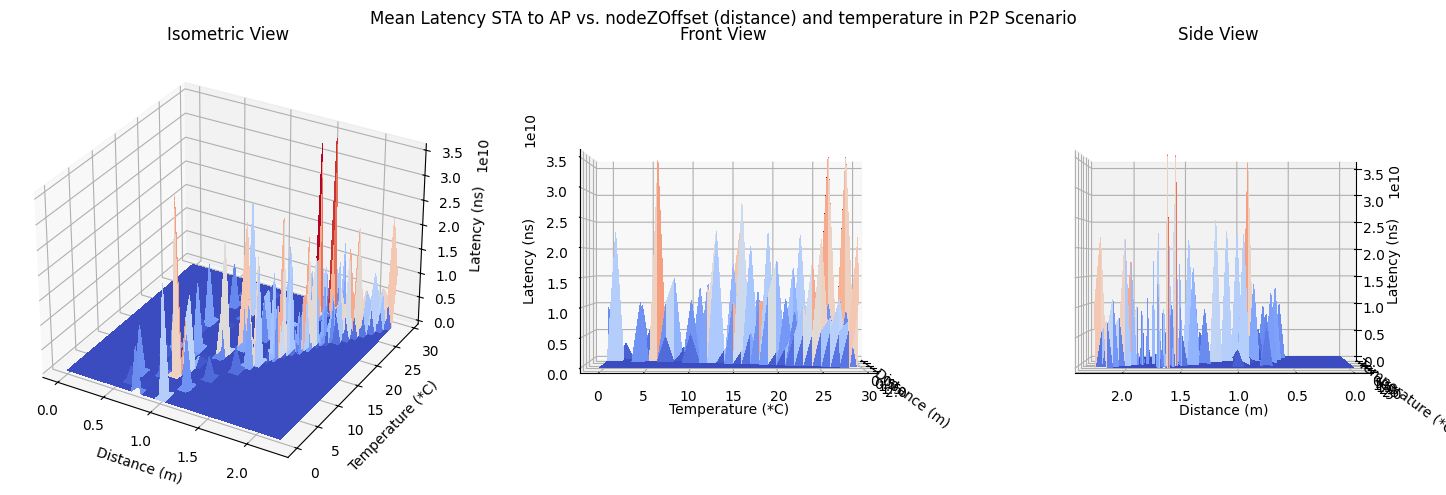

In [7]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean Latency STA to AP vs. nodeZOffset (distance) and temperature in P2P Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(packet_logging_stats_summary['nodeXOffset'].unique())
y_unique = np.sort(packet_logging_stats_summary['waterTemperature'].unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_x_offset = x_unique[i]
        node_temperature = y_unique[j]
        mask = (packet_logging_stats_summary['nodeXOffset'] == node_x_offset) & \
               (packet_logging_stats_summary['waterTemperature'] == node_temperature)
        if mask.any():
            Z[j, i] = packet_logging_stats_summary.loc[mask, 'MeanLatencySTAToAP'].mean()

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax1.set_xlabel('Distance (m)')
ax1.set_ylabel('Temperature (*C)')
ax1.set_zlabel('Latency (ns)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Temperature (*C)')
ax2.set_zlabel('Latency (ns)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax3.set_xlabel('Distance (m)')
ax3.set_ylabel('Temperature (*C)')
ax3.set_zlabel('Latency (ns)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()

In [8]:
# Convert time from ns to h
for col in filter(lambda x: x.endswith('Time'), power_state_stats.columns):
    power_state_stats[col] = power_state_stats[col] / 1e9 / 3600

# Multiply the time by the power consumption of each state
# Constants from https://www.nsnam.org/docs/release/3.23/doxygen/classns3_1_1_wifi_radio_energy_model.html
voltage = 3
power_state_stats['RXPower'] = power_state_stats['RXTime'] * voltage * 0.313
power_state_stats['TXPower'] = power_state_stats['TXTime'] * voltage * 0.38
power_state_stats['IDLEPower'] = power_state_stats['IDLETime'] * voltage * 0.273
power_state_stats['SLEEPPower'] = power_state_stats['SLEEPTime'] * voltage * 0.033
power_state_stats['CCA_BUSYPower'] = power_state_stats['CCA_BUSYTime'] * voltage * 0.273
power_state_stats['SWITCHINGPower'] = power_state_stats['SWITCHINGTime'] * voltage * 0.273
power_state_stats['TotalPower'] = power_state_stats['RXPower'] + power_state_stats['TXPower'] + power_state_stats['IDLEPower'] + power_state_stats['SLEEPPower'] + power_state_stats['CCA_BUSYPower'] + power_state_stats['SWITCHINGPower']

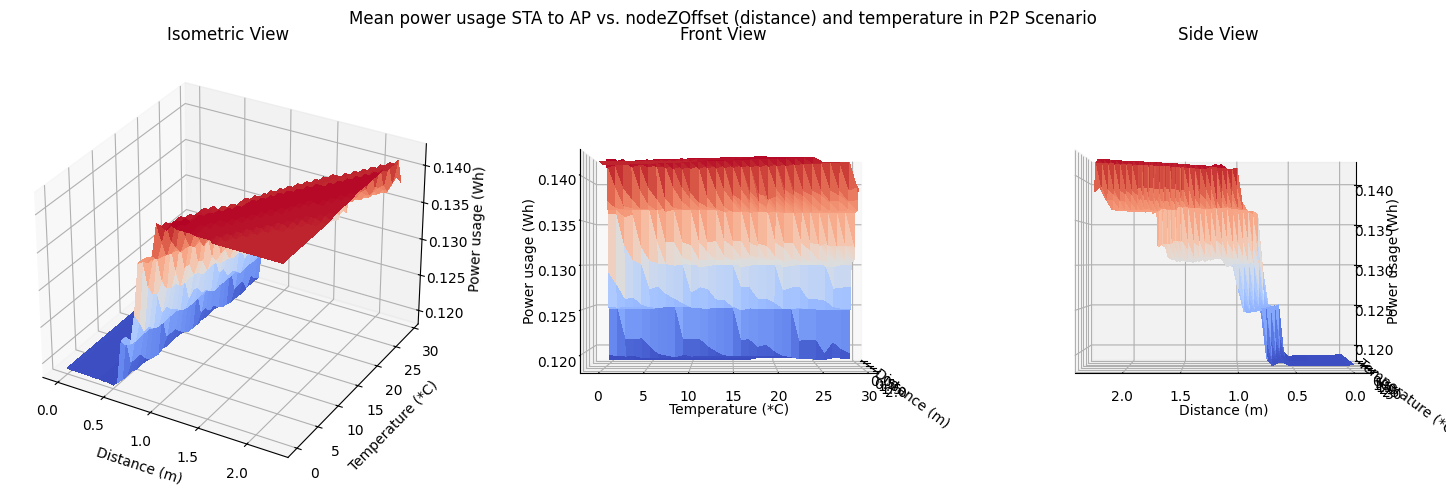

In [9]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean power usage STA to AP vs. nodeZOffset (distance) and temperature in P2P Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(power_state_stats['nodeXOffset'].unique())
y_unique = np.sort(power_state_stats['waterTemperature'].unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_x_offset = x_unique[i]
        node_temperature = y_unique[j]
        mask = (power_state_stats['nodeXOffset'] == node_x_offset) & \
               (power_state_stats['waterTemperature'] == node_temperature)
        if mask.any():
            Z[j, i] = power_state_stats.loc[mask, 'TotalPower'].mean()

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax1.set_xlabel('Distance (m)')
ax1.set_ylabel('Temperature (*C)')
ax1.set_zlabel('Power usage (Wh)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Temperature (*C)')
ax2.set_zlabel('Power usage (Wh)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax3.set_xlabel('Distance (m)')
ax3.set_ylabel('Temperature (*C)')
ax3.set_zlabel('Power usage (Wh)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()